In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  

In [151]:
df = pd.read_csv(r'C:\Upgrad\Python\Bank Marketing\Data\bank.csv')

In [152]:
df.shape

(4521, 1)

In [153]:
df = pd.read_csv(r'C:\Upgrad\Python\Bank Marketing\Data\bank.csv', sep=';')

# Understand Data

Model learns patterns from data. If we don't understand the data, we won't be able to understand the model.

In [154]:
# Target Variable 


df['y'].value_counts()



y
no     4000
yes     521
Name: count, dtype: int64

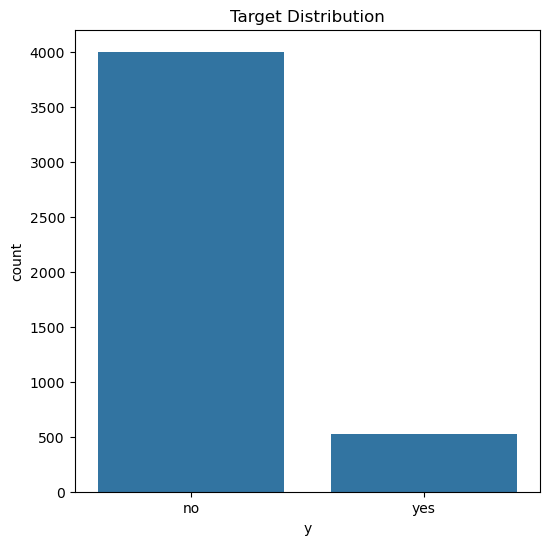

In [155]:
plt.figure(figsize=(6,6))
sns.countplot(x='y', data=df)
plt.title('Target Distribution')
plt.ylabel('count')
plt.show()

1. Most customers say No
2. very few said YEs
3. This is called **class imbalence**
4. This will matter later when we evaluate model

In [156]:
# numeric columns
numeric_cols = df.select_dtypes(include='int64').columns

In [157]:
# numeric_cols
# these are numeric columns. we can plot them to understand sread and xscale

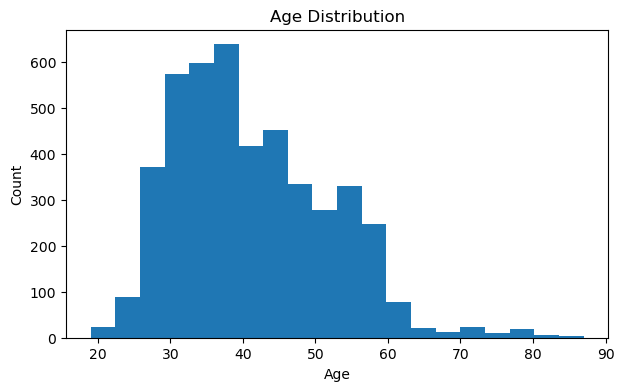

In [158]:
# Age Distribution

plt.figure(figsize=(7,4))   
plt.hist(df['age'], bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count') 
plt.show()

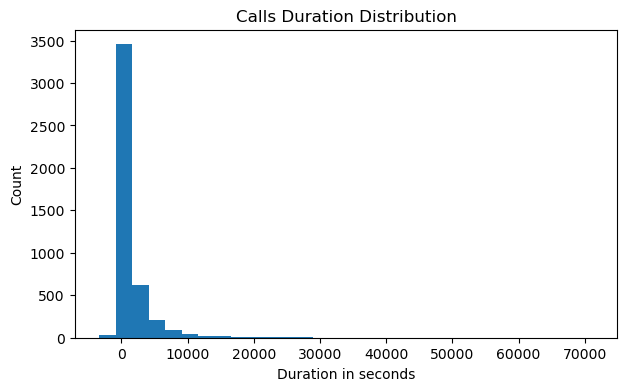

In [159]:
# 
plt.figure(figsize=(7,4))
plt.hist(df['balance'], bins=30)
plt.title('Calls Duration Distribution')
plt.xlabel('Duration in seconds')
plt.ylabel('Count')
plt.show()  

1. Features are skewed
2. Some have very large ranges
3. Therefor **Scaling is needed**

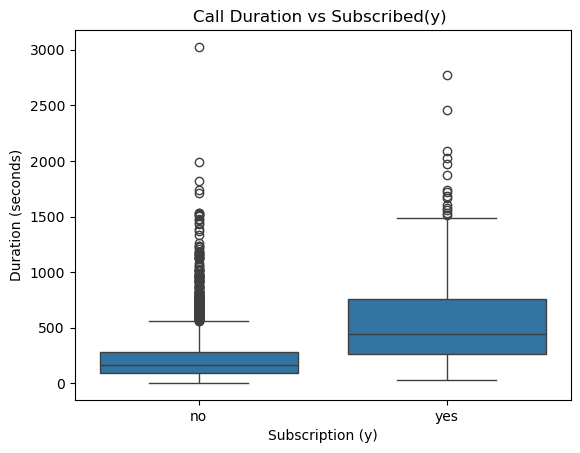

In [160]:
# duration vs y(target)
sns.boxplot(x='y', y='duration', data=df)
plt.title('Call Duration vs Subscribed(y) ')
plt.xlabel('Subscription (y)')
plt.ylabel('Duration (seconds)')    
plt.show()

Customers who says **YES** generally have longer call duration

# Classification

### 1. Seprate X( Features ) and y( target )

In [161]:
X = df.drop('y', axis=1)


In [162]:
y = df['y'] 

In [163]:
X.shape

(4521, 16)

In [164]:
y.shape

(4521,)

### 2. Numeric and category col

In [165]:
cat_cols = X.select_dtypes(include='object').columns   
num_cols = X.select_dtypes(include='int64').columns


1. Catgeory : **Encoding**
2. Numeric : **Scaling**


### 3. Encoding

In [166]:
X__encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)   

In [167]:
print("Befor encoding:", X.shape)

Befor encoding: (4521, 16)


In [168]:
print("After encoding :", X__encoded.shape )

# After encoding, everything is numeric becomes numeric ( 0 and 1 columns are created )

After encoding : (4521, 42)


### 4. Train Test Split

In [169]:
from sklearn.model_selection import train_test_split

In [170]:
X_train, X_test, y_train, y_test = train_test_split(X__encoded, y, test_size=0.2, random_state=42, stratify=y)  


In [171]:
print(X_train.shape, X_test.shape)

(3616, 42) (905, 42)


### 5. Scaling

In [172]:
from sklearn.preprocessing import StandardScaler


In [173]:
scaler = StandardScaler()


In [174]:
# Making copies so that we don't mess up original dataframe
X_train_scaled= X_train.copy()
X_test_scaled= X_test.copy()

In [175]:
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols]) # fit on train numeric co only

In [176]:
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])  # transform  test numeric col only ( no fit here )

1. train data decideds scaling rules.
2. Test data only follows those rules.
3. **No data leakage** : the model accidentially gets access to information from the testing while it is still learning.

### 6. Train Logistic Regression.

In [177]:
from sklearn.linear_model import LogisticRegression

In [178]:
model = LogisticRegression(max_iter=500)
model.fit(X_train_scaled, y_train)  


LogisticRegression(max_iter=500)

### 7. Prediction

In [179]:
y_pred = model.predict(X_test_scaled)   

### 8. Evaluation

**Accuracy + Confusion Matrix + Classification Report**

In [180]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [181]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy on test set:", acc) 

Accuracy on test set: 0.8928176795580111


In [182]:
cm = confusion_matrix(y_test, y_pred, labels=['no', 'yes'])
cm

array([[777,  24],
       [ 73,  31]])

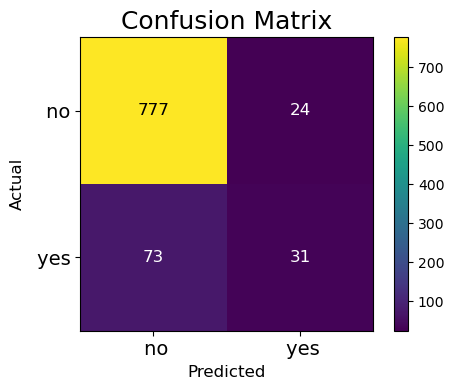

In [183]:
plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title('Confusion Matrix', fontsize=18)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)


plt.xticks([0,1], [' no', ' yes'], fontsize=14)
plt.yticks([0,1], [' no', ' yes'], fontsize=14)

for i in range(2):
    for j in range(2):
        val = cm[i,j]
        if val > cm.max()/2:
            color = 'black'
        else:
            color = 'white'
        plt.text(j, i, val, ha='center', va='center', fontsize=12, color=color)

plt.colorbar()  
plt.tight_layout()  


ROWS = **Actual**  Columns = **Predicted**

1. TOP LEFT = **correct NO**
2. BOTTOM LEFT = **correct YES**
3. BOTTTOM LEFT = **missed YES**
4. TOP RIGHT = **false YES**

In [184]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          no       0.91      0.97      0.94       801
         yes       0.56      0.30      0.39       104

    accuracy                           0.89       905
   macro avg       0.74      0.63      0.67       905
weighted avg       0.87      0.89      0.88       905



### 

# improving **'YES'** Class Performance

from cunfusion_metrix

  - False Negative = 70
  - True positive = 30

ours model is missing any customers who would atually subscribed. so we want to model to identify more **S** Customers

In [185]:
y_prob = model.predict_proba(X_test_scaled)
y_prob[:5]

# col 0 : probability if NO
# col 1 : probability if YES

array([[0.81544881, 0.18455119],
       [0.97371278, 0.02628722],
       [0.97384245, 0.02615755],
       [0.98856985, 0.01143015],
       [0.97938451, 0.02061549]])

In [186]:
y_yes_prob = y_prob[:, 1]  

# This co tells us how confidential the model is that the customer will say YES

In [187]:
y_pred_default = model.predict(X_test_scaled)

In [188]:
threshold = 0.3

y_pred_30 = []
for p in y_yes_prob:
    if p >= threshold:
        y_pred_30.append("yes")
    else:
        y_pred_30.append("no")

In [189]:
cm_30 = confusion_matrix(y_test, y_pred_30, labels=['no','yes'])
print(cm_30)

[[747  54]
 [ 54  50]]


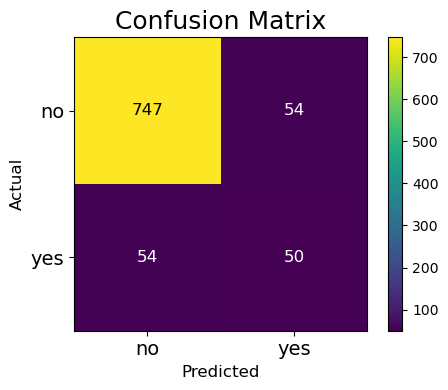

In [190]:
plt.figure(figsize=(5,4))
plt.imshow(cm_30)
plt.title("Confusion Matrix", fontsize=18)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)

plt.xticks([0,1], ['no', 'yes'], fontsize=14)
plt.yticks([0,1],['no','yes'],fontsize=14)


for i in range(2):
    for j in range(2):
        val = cm_30[i,j]
        if val > cm_30.max()/2:
            color = 'black'
        else:
            color = 'white'
        plt.text(j,i,val, ha='center',va='center',fontsize=12,color=color)


plt.colorbar()
plt.tight_layout()

In [191]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_30))

              precision    recall  f1-score   support

          no       0.93      0.93      0.93       801
         yes       0.48      0.48      0.48       104

    accuracy                           0.88       905
   macro avg       0.71      0.71      0.71       905
weighted avg       0.88      0.88      0.88       905

